<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Смирнов Сергей Артёмович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №1

### $\space$ Дано:
* $P_0 = 23.4 \space МПа $ - Давление перед турбиной
* $t_0 = 545 ^\circ C$ -  Температура перед турбиной
* $P_{пп} = 3.3 \space МПа$ -  Давление промперегрева
* $t_{пп} = 545 ^\circ C$ -  Температура промперегрева
* $P_{к} = 5 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 263^\circ C$ -  Температура питательной воды

* $N_{э} = 320 \space МВт$ -  Электрическая мощность
* z = 9 -  Количество перегревателей

# 1. Построение процесса расширения пара в турбине. Определение расходов пара на входе в турбину $G_0$ и в конденсатор $G_к$.

In [1]:
from G_2 import calc_mass_flow
from G_2 import r
from steam import Steam as my_steam

In [2]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None

In [3]:
p0 = 25 * MPa
G_calc = my_steam(name = "steam", R = 461, c_p =287.05)
A = calc_mass_flow(G_calc,
                   p0 = 23.4 * MPa ,
                   t0 = 545 ,
                   p_middle = 3.3 * MPa ,
                   t_middle = 545 ,
                   pk = 5 * kPa, 
                   t_feed_water = 263,
                   p_feed_water = 1.35 * p0,

                   electrical_power = 320*10**6,
                   internal_efficiency = 0.85,
                   mechanical_efficiency = 0.995,
                   generator_efficiency = 0.99,
                   alpha = 0.83)

inlet_mass_flow = A.inlet_mass_flow
condenser_mass_flow = A.condenser_mass_flow
print("Расход на входе в турбину: ",r(inlet_mass_flow), "кг /с")
print("Расход на входе в конденсатор: ",r(condenser_mass_flow), "кг/с")

Расход на входе в турбину:  260 кг /с
Расход на входе в конденсатор:  177 кг/с


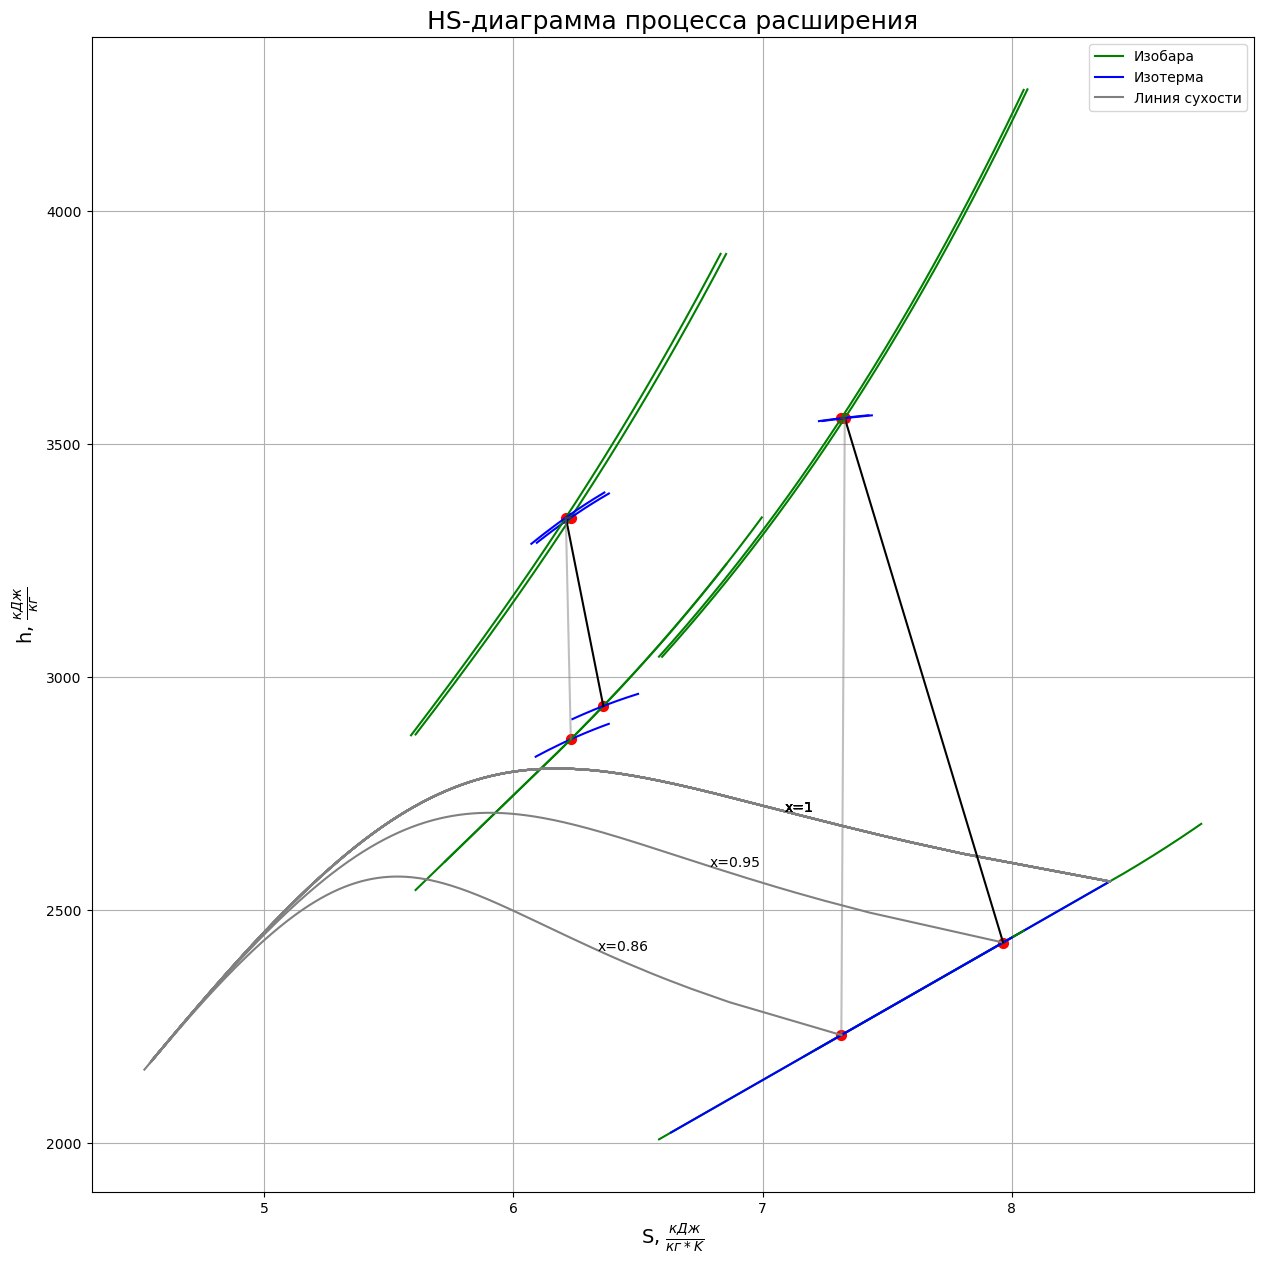

In [4]:
A.all_hs_plot

# Задание 2

Проведение расчёта регулирующей ступени и определние зависимости $\eta_{ол}$ от $U/c_f$. Диапазон варирьуемого параметра - диаметра - задан; обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

Выберем в качестве сопловой лопатки *С-90-12А*, в качестве рабочей: *Р-26-17А*
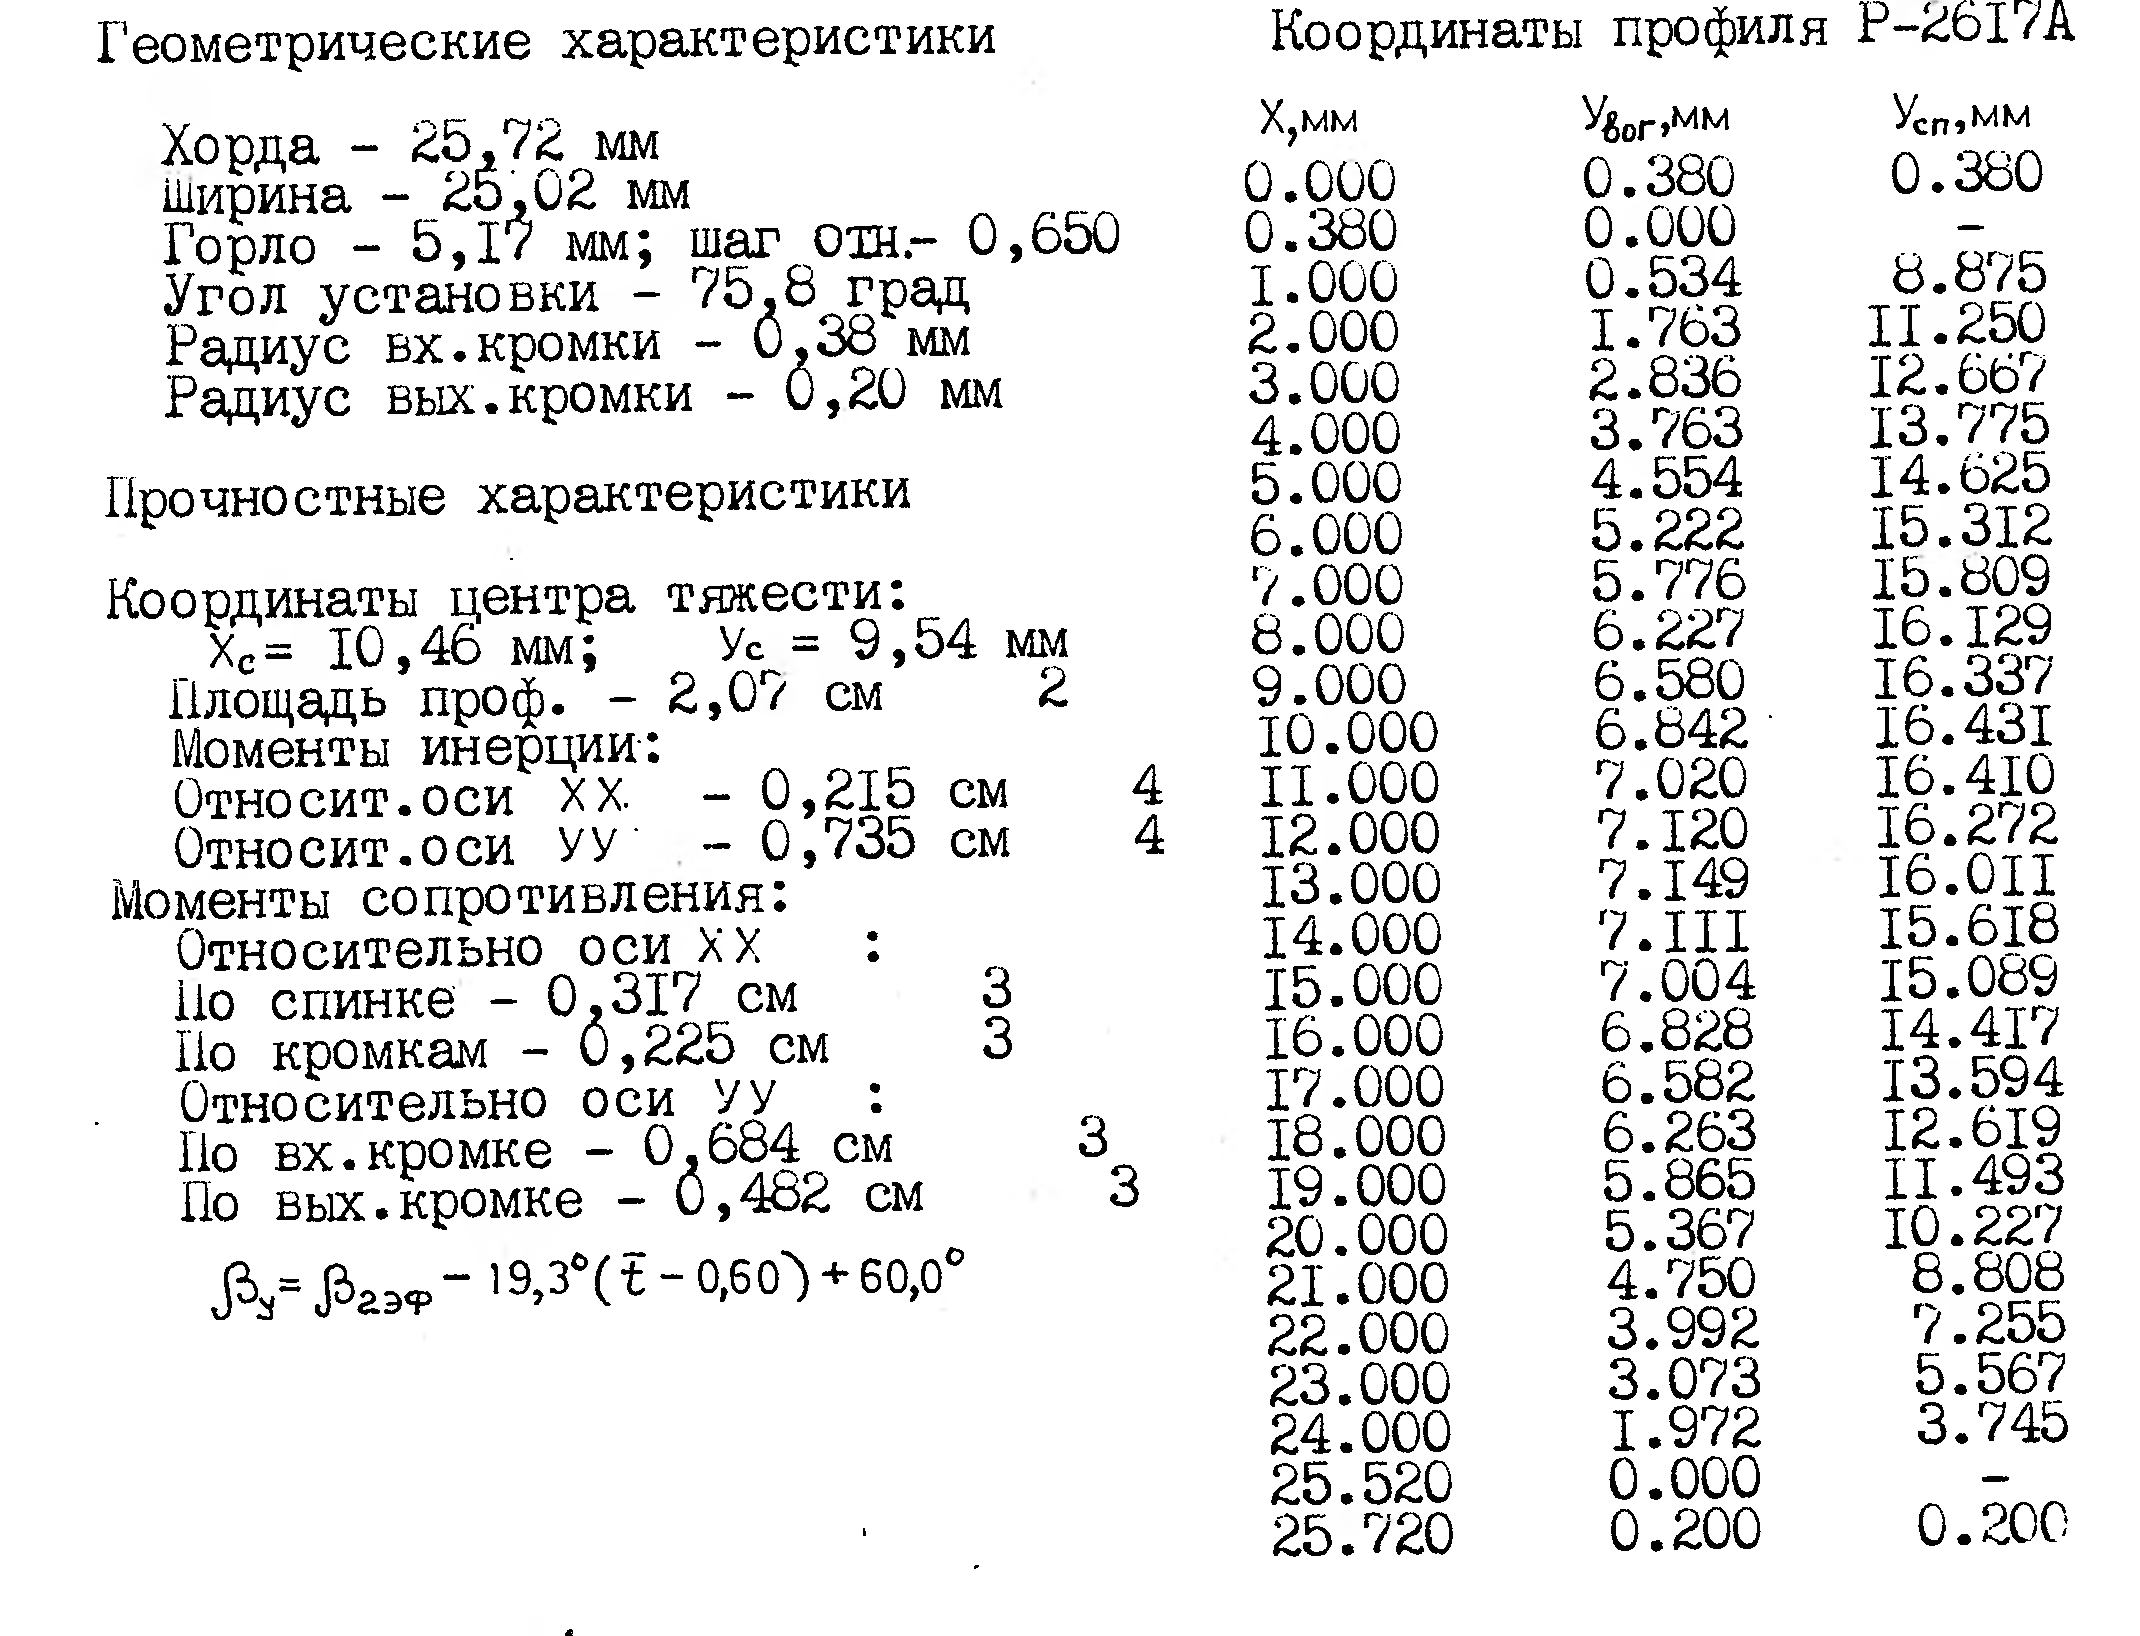

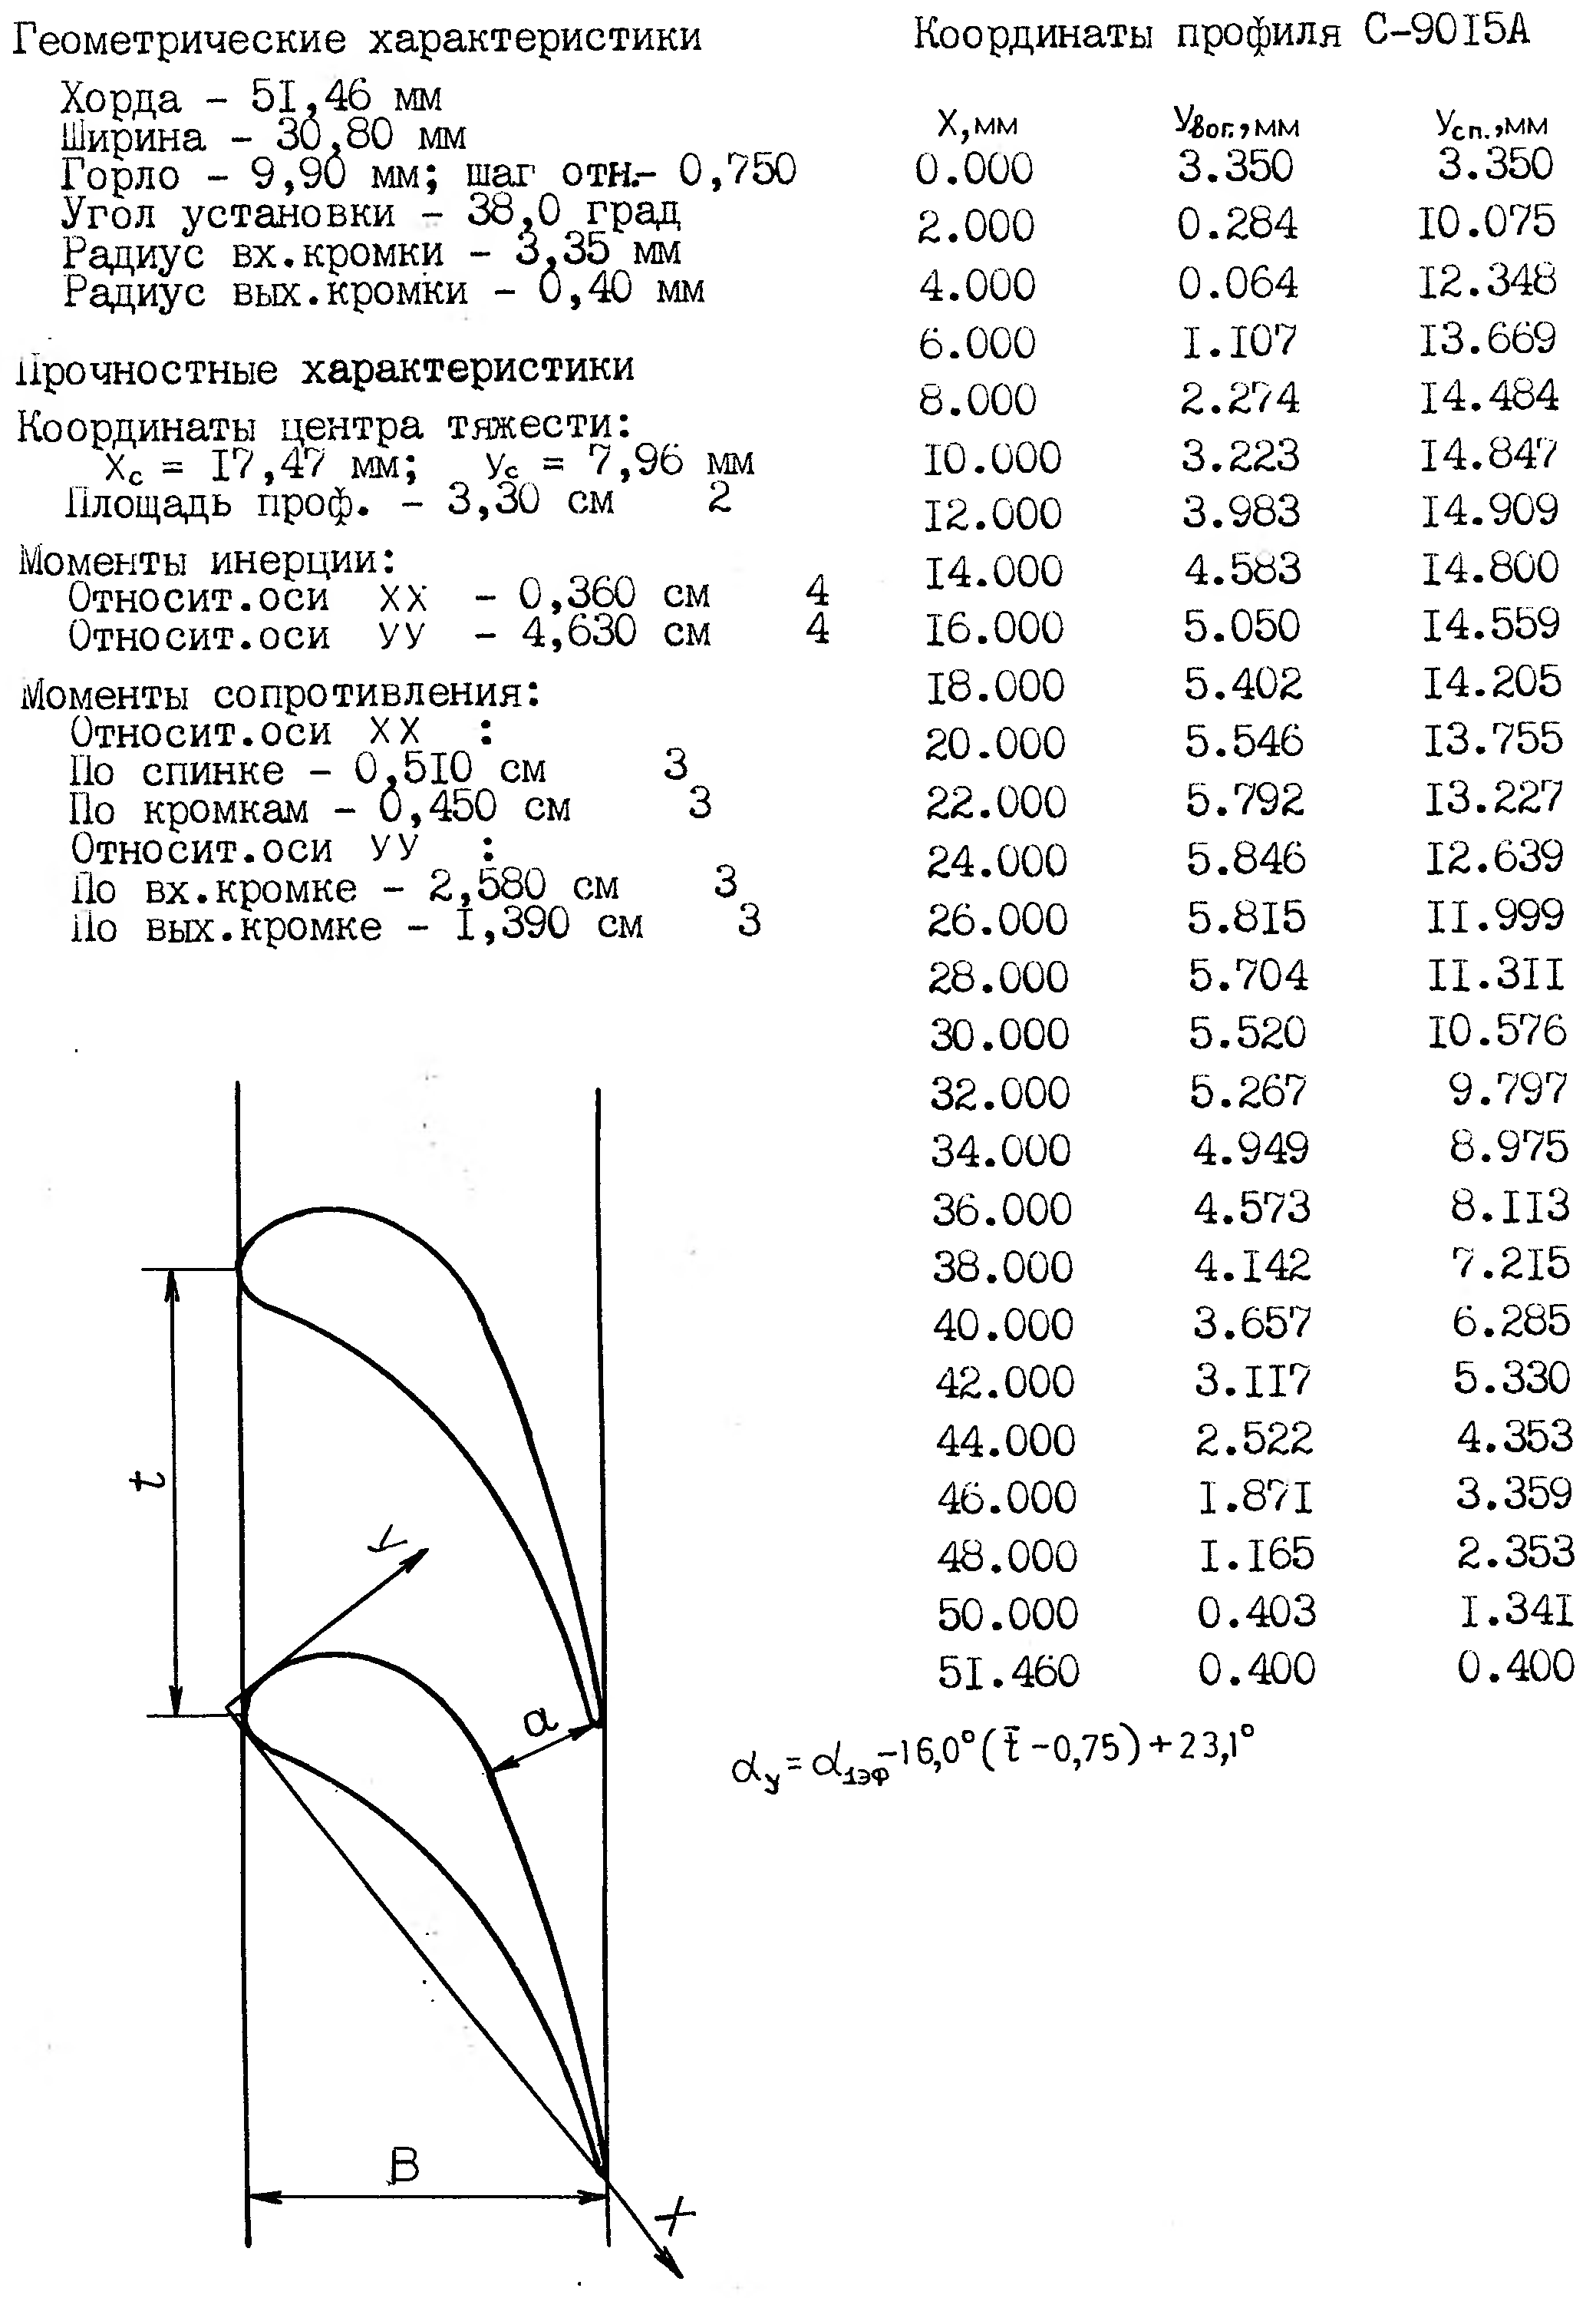

In [4]:
import numpy as np
import matplotlib.pyplot as plt
H_o = 100
k = 1.33
n = 60
rho = 0.1
b_1 = 51.5
d =0.9
p0 = 23.4 * MPa
t0 = 545
alpha_1_e = 15
t_1opt = (0.7+0.87)/2
t_opt_2 = (0.60+0.70)/2
b_2 = 25.7
G = inlet_mass_flow = 257.13
pere = 0.003
xi_vs = 0
d_r = np.arange(0.9,1.1,0.01) 
# for i in range (9000, 11001, 1):
    # d_r.append(i*0.0001)

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_28216\4228420852.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel(f"$\eta$, %")
C:\Users\Vait_\AppData\Local\Temp\ipykernel_28216\4228420852.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(d_r,_eff_ol_energy , col

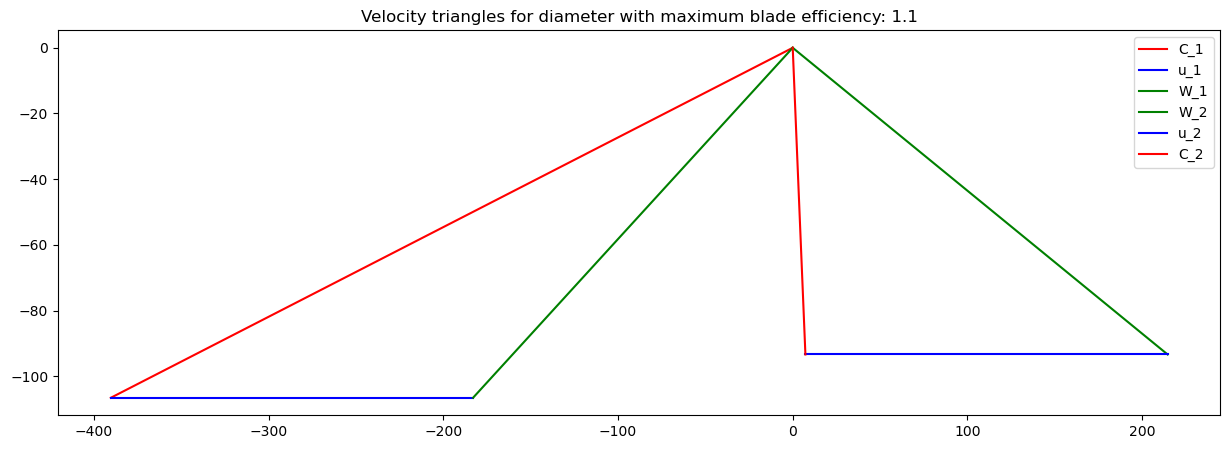

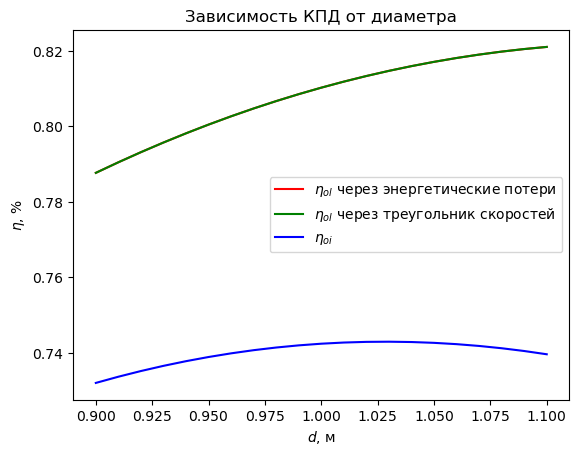

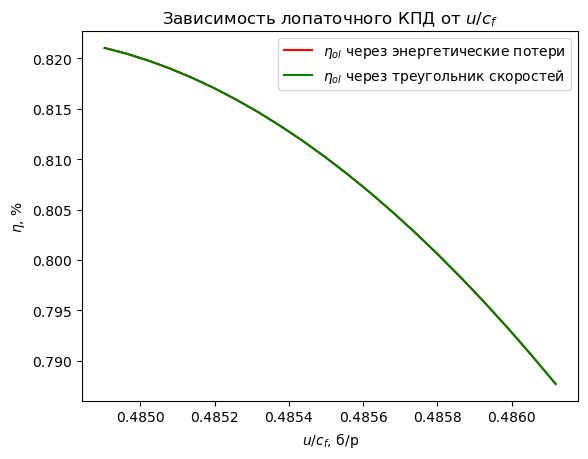

In [6]:
_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
for i in range(len(d_r)):
    eff_ol_energy, eff_ol_angle, eff_oi, u_cf = A.efficiency_oi_ol (H_o, p0,t0, k, n, rho, b_1, alpha_1_e, t_1opt, t_opt_2, b_2, G, pere, xi_vs, d_r[i])
    _eff_ol_energy.append(eff_ol_energy)
    _eff_ol_angle.append(eff_ol_angle)
    _eff_oi.append(eff_oi)
    _u_cf.append(u_cf)

# fig, ax = plt.subplots(1, 1, figsize=(15,5))
# ax.plot(range(d_r, _eff_ol_energy, legend = "")
# ax.plot(range(d_r, _eff_ol_energy)

# ax.set_xlabel("Номер ступени")
# ax.set_ylabel(ax_name)
# ax.grid()
plt.title("Зависимость КПД от диаметра") 
plt.xlabel(f"$d$, м") 
plt.ylabel(f"$\eta$, %")     
plt.plot(d_r,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(d_r,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.plot(d_r,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.legend()
plt.show()

plt.title("Зависимость лопаточного КПД от $u/c_f$") 
plt.xlabel(f"$u/c_f$, б/р") 
plt.ylabel(f"$\eta$, %")     
plt.plot(_u_cf,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(_u_cf,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.legend()
plt.show()